# **8주차: Natural Language Processing**

In [ ]:
!pip install torch
!pip install datasets
!pip install konlpy
!pip install gensim

## **텍스트 데이터**

텍스트 데이터는 문장이나 단어들로 구성된 데이터로,

문장이나 단어를 토큰 단위로 쪼갠 후, 토큰별로 하나의 벡터값을 가지는 방식으로 표현할 수 있음 </br> </br>

<img src="https://velog.velcdn.com/images/ddophi98/post/71304bbd-5176-412b-904d-08e6043c6a3a/image.png" width=500> </br> </br>

$T$는 문장의 길이(문장에 들어있는 토큰 수), $C$는 특성의 수라고 생각하면

텍스트 데이터의 형태는 $(T, C)$로 표현 가능함

### **텍스트 데이터의 특성**

#### **중의성 및 모호성 (Ambiguity)**

<img src="https://blog.kakaocdn.net/dn/0Od2o/btrgD3uHuKw/H108kVZuKRaJBxRgM7EAgk/img.png" width=500> </br> </br>

하나의 단어가 다양한 의미를 가지고 있기도 하고, 하나의 상황을 설명하는데에 있어서 다양하게 표현을 할 수 있음

혹은 동일한 문장, 동일한 단어를 사용한다고 해도 상황에 따라 다르게 해석될 여지가 있음



#### **순차적 특성**

<img src="https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fl3ZjN%2Fbtq0UcMPfkX%2FuHByRk5mM7Nhg1cMhZKn80%2Fimg.png" width=350> </br> </br>

문장에서 각 단어는 앞선 단어들에 의해 영향을 받으며, 이러한 관계는 순차적으로 연결됨

단어가 순차적으로 나오면서 문맥을 형성하고, 이를 통해 단어가 어떤 의미로 해석될지 결정됨

### **텍스트 데이터에 MLP를 이용한다면?**

먼저, 텍스트 데이터의 각 토큰들의 벡터를 하나로 합쳐 $(TC)$ 형태의 벡터로 만든 후,

MLP에 입력값으로 넣는 경우를 고려해볼 수 있음 </br> </br>

<img src="https://i.ibb.co/yBp6M3V/Kakao-Talk-Photo-2024-11-20-18-07-04.png" width=400> </br> </br>

이러한 방식은 각 시점 간의 관계를 학습할 수 있지만 동적인 관계는 학습하지 않고 정적인 관계를 학습하게 됨

각 시점의 토큰들은 문장별로 다른 관계를 가지는데, MLP로는 단순히 한 가지의 관계밖에 학습하지 못하는 특징을 가짐 </br> </br>

또한, 문장별로 길이가 다른 경우가 대부분인데, 입력 차원은 항상 $TC$로 고정되어 있기 때문에 테스트 시 다른 길이를 가진 문장들은 모델에 넣지 못하고,

문장 길이에 따라 입력 차원 수가 매우 커지기 때문에, 비효율적으로 학습되고 가중치가 너무 많아져 과적합이 발생하기 쉬운 한계가 있음 </br> </br>


다음으로 텍스트 데이터의 각 토큰들의 벡터들을 모두 더하거나 평균을 내어 $(C)$ 형태의 벡터를 만드는 방법도 고려해볼 수 있음 </br> </br>
 
<img src="https://i.ibb.co/0KWvHYM/Kakao-Talk-Photo-2024-11-22-16-43-36.png" width=500> </br> </br>

이러한 방식은 가변적인 길이를 가지는 문장을 입력을 받을 수 있고, 입력 차원의 크기 또한 크게 줄일 수 있지만,

토큰들의 순서가 달라져도 항상 같은 입력값을 가지게 되므로 각 시점간의 관계를 고려할 수 없다는 한계가 있음 </br> </br>

따라서, 텍스트 데이터는 효율적이면서 각 시점간의 동적인 관계를 학습할 수 있는 모델 구조가 필요함

**텍스트 데이터 예시**

In [ ]:
from datasets import load_dataset

# 데이터셋 불러오기
dataset = load_dataset("Blpeng/nsmc",   # 허깅페이스 레포 id
                       split="train")   # 데이터셋 유형

# 문장 샘플 출력
for i in range(5):
    print(f"문장{i+1}: {dataset[i]['document']}")

## **워드 임베딩 (Word Embedding)**

자연어 처리(NLP)에서 단어를 연속적인 벡터 형태로 표현하는 방법

컴퓨터가 인간이 사용하는 언어를 이해하고, 분석할 수 있도록 하려면, 기본적으로 컴퓨터가 사용하는 방식으로 사람의 언어를 변환해야 함 </br> </br>

<img src="https://blog.kakaocdn.net/dn/cnRGI8/btrrW3o5Mv9/KX1kLXT6koOmfYDDdHKyv0/img.png" width=450> 

### **토크나이저 (Tokenizer)**

텍스트 데이터를 활용한다면, 먼저 모델이 사용할 수 있는 단위로 바꾸어주어야 하는데,

토크나이저는 문장이나 단어들로 구성된 텍스트를 토큰 단위로 나누고 변환하는 토큰화 과정을 수행하며, 각 토큰을 정수(ID)로 매핑하는 역할을 수행함 </br> </br>

<img src="https://codetorial.net/tensorflow/_images/natural_language_processing_in_tensorflow_02.png" width=350> </br> </br>

토큰으로는 단어, 부분 단어, 문자 등이 활용될 수 있으며, 토크나이저별로 사용되는 토큰은 다름

또한, 토크나이저에서 정의된 토큰들의 집합을 사전 (Vocabulary)이라고 부름

*정수로 매핑된 토큰은 이후 각 토큰별 임베딩 벡터가 저장되어 있는 Lookup Table에 인덱스로 활용하게 됨

**토크나이저 예시**

In [ ]:
from konlpy.tag import Okt

# 토크나이저 정의
okt = Okt()

# 문장 토큰화
sent = "나는 맛있는 저녁을 먹었다."
tokenized_sent = okt.morphs(sent)

# 토큰화된 문장 출력
print(tokenized_sent)

### **희소 표현 (Sparse Representation)**

토큰들을 벡터화하는 방법 중에서 가장 쉽게 생각해볼 수 있는 방법은 원-핫 인코딩을 활용하는 것임 

토큰들의 임베딩 벡터를 원-핫 인코딩 벡터로 표현하여 각 토큰들을 구분해줄 수 있음 </br> </br>

<img src="https://oopy.lazyrockets.com/api/v2/notion/image?src=https%3A%2F%2Fs3-us-west-2.amazonaws.com%2Fsecure.notion-static.com%2F6875da2e-9ec3-435a-8e0f-bd4c1d4a8463%2FUntitled.png&blockId=29bc9716-d102-4a2c-83eb-966f6d3b876e" width="300"> </br> </br>

하지만, 원-핫 인코딩 벡터를 활용하게 된다면 사전의 크기가 늘어날수록 임베딩 벡터의 차원수도 똑같이 늘어나기 때문에 비효율적이고,

각 토큰 간의 관계나 유사성을 표현할 수 없다는 한계가 있음

**원-핫 인코딩 예시**

In [ ]:
import torch
import torch.nn.functional as F
from konlpy.tag import Okt

# 토크나이저 정의
okt = Okt()

# 문장 토큰화
sent = "나는 맛있는 저녁을 먹었다."
tokenized_sent = okt.morphs(sent)

# 토큰화된 문장을 바탕으로 사전 생성
vocab = {token: idx for idx, token in enumerate(set(tokenized_sent))}

# 각 토큰을 정수로 매핑 후 원-핫 인코딩 벡터로 변환
token_idxs = torch.LongTensor([vocab[token] for token in tokenized_sent])
one_hot = F.one_hot(token_idxs,                 # 토큰 인덱스 데이터
                    num_classes=len(vocab))     # 클래스 개수

# 각 토큰별 임베딩 벡터 출력
for token, vec in zip(tokenized_sent, one_hot):
    print(f"{token}: {vec}")

### **밀집 표현 (Dense Representation)**

희소 표현은 각 토큰들의 임베딩 벡터를 0과 1만으로 표현하는 반면,

밀집 표현은 임베딩 벡터의 임베딩 차원을 임의로 설정하고, 모든 값들을 연속적인 실수로 표현하는 방식임 </br> </br>

밀집 표현을 이용하면, 적은 차원으로도 각각의 토큰들을 구분해줄 수 있다는 장점이 있으며,

임베딩 벡터는 모델과 같이 학습을 시키커나 아니면 모델 학습 전에 미리 텍스트 데이터를 통해 학습시킬 수도 있는데,

모델 학습 전에 미리 임베딩 벡터를 학습시키는 방법에는 Word2Vec, GloVe, FastText 등이 있음

**밀집 표현 예시**

In [ ]:
import torch
import torch.nn as nn
from konlpy.tag import Okt

# 토크나이저 정의
okt = Okt()

# 토큰화
sent = "나는 맛있는 저녁을 먹었다."
tokenized_sent = okt.morphs(sent)

# 토큰화된 문장을 바탕으로 단어 사전 생성
vocab = {token: idx for idx, token in enumerate(set(tokenized_sent))}

# 밀집 표현의 임베딩 행렬 정의
embed_dim = 5
embedding = nn.Embedding(len(vocab),    # 단어 사전 크기
                         embed_dim)     # 워드 벡터 임베딩 차원수

# 각 토큰별 임베딩 벡터 출력
for token in tokenized_sent:
    x = torch.tensor(vocab[token], dtype=torch.long)    # 토큰을 인덱스로 변환
    print(f"{token}: {embedding(x).data}")

### **Word2Vec**

Word2Vec은 2013년 Google에서 개발한 워드 임베딩 방법 중 하나로, 

"비슷한 의미를 가지는 단어는 비슷한 문맥에서 등장한다"라는 분포 가설(Distributional Hypothesis)을 기반으로 함 </br> </br>

<img src="https://community.alteryx.com/t5/image/serverpage/image-id/45458iDEB69E518EBA3AD9?v=v2" width=500> </br> </br>

분포 가설을 바탕으로 각 토큰들의 임베딩 벡터는 문장에서 등장하는 주변 토큰들의 임베딩 벡터와 가까워지도록 학습을 진행하는데,

이러한 원리를 기반으로 학습 시키는 방법으로는 CBOW, Skip-Gram 두 가지가 있음

#### **CBOW (Continuous Bag of Words)**

CBOW는 주변 문맥 단어들을 기반으로 중심(타겟) 단어를 예측하는 방식으로 학습을 진행하는데,

예를 들어, "나는 맛있는 저녁을 먹었다."라는 문장이 있다면, 

"저녁을"이라는 타겟 단어를 예측하기 위해 ["맛있는", "먹었다."]의 주변 문맥 단어를 입력으로 활용하는 방식임 </br> </br>

<img src="https://production-media.paperswithcode.com/methods/Screen_Shot_2020-05-26_at_2.04.47_PM.png" width=250> </br> </br>

$ P(w_{t} \mid w_{t-\frac{c}{2}}, ..., w_{t-1}, w_{t+1}, w_{t+\frac{c}{2}}) = \dfrac{exp(v_{w_{t}} \cdot \hat{v})}{\sum_{w \in V} exp(v_{w} \cdot \hat{v})} \\
L = - \dfrac{1}{T} \sum^{T}_{t=1} log P(w_{t} \mid w_{t-\frac{c}{2}}, ..., w_{t-1}, w_{t+1}, w_{t+\frac{c}{2}}) $

<span style="font-size: 13px">

$v_{w_{t}}$: 중심 단어의 임베딩 벡터 &#160;&#160; $\hat{v}$: 주변 문맥 단어들의 평균 임베딩 벡터 &#160;&#160; $V$: 임베딩 벡터들의 집합 &#160;&#160; $c$: 윈도우 크기  &#160;&#160; $T$: 문장 길이 

</span>
</br>

중심 단어에 대해 앞 뒤로 $\frac{c}{2}$개 씩 총 $c$개의 단어를 주변 문맥 단어로 사용하여,

각 시점에 대해 주변 문맥 단어들의 평균 임베딩 벡터와 중심 단어의 임베딩 벡터 사이에는 유사도가 커지도록, 

나머지 단어들의 임베딩 벡터 사이에는 유사도가 낮아지도록 학습이 진행되는 원리임 </br> </br>

CBOW 방식은 여러 문맥 단어의 평균을 사용하여 중심 단어를 예측하므로, 

소규모 데이터셋에서도 빠르고 안정적으로 학습할 수 있는 반면,

평균을 사용하여 문맥 정보를 압축하므로, 정보 손실이 발생하여 일반적으로 Skip-Gram 방식보다 성능이 떨어짐

#### **Skip-Gram**

Skip-Gram은 중심(타겟) 단어로 주변 문맥 단어들을 예측하는 방식으로 학습을 진행하는데,

예를 들어, "나는 맛있는 저녁을 먹었다."라는 문장이 있다면, 

"저녁을"이라는 단어가 주어졌을 때 ["맛있는", "먹었다."]의 주변 문맥 단어들을 예측하는 방식임 </br> </br>

<img src="https://machinelearninginterview.com/wp-content/uploads/2019/02/skipgram_model.png" width=250> </br> </br>

$ P(w_{i} \mid w_t) = \dfrac{exp(v_{w_{i}} \cdot v_{w_t})}{\sum_{w \in V} exp(v_{w} \cdot v_{w_{t}})} \\
L = - \dfrac{1}{T} \sum^{T}_{t=1} \sum_{-\frac{c}{2} \leq i \leq \frac{c}{2}, i \neq 0} log P(w_{i} \mid w_{t}) $

<span style="font-size: 13px">

$w_{t}$: 중심 단어 &#160;&#160; $v_{w_{t}}$: 중심 단어의 임베딩 벡터  &#160;&#160; $V$: 임베딩 벡터들의 집합 &#160;&#160; $c$: 윈도우 크기  &#160;&#160; $T$: 문장 길이 

</span>
</br>

CBOW와 마찬가지로 중심 단어에 대해 앞 뒤로 $\frac{c}{2}$개 씩 총 $c$개의 단어를 주변 문맥 단어로 사용하여,

중심 단어의 임베딩 벡터와 주변 문맥 단어들의 각 임베딩 벡터 사이에는 유사도가 커지도록, 

나머지 단어들의 임베딩 벡터와는 유사도가 낮아지도록 학습이 진행되는 원리임 </br> </br>

Skip-Gram 방식은 중심 단어로 주변 문맥 단어를 예측하므로, 

대규모 데이터셋에서 단어의 다양한 의미를 학습하고 드물게 나오는 단어에 대해서도 효과적으로 학습할 수 있는 반면,

계산량이 CBOW 발식보다 많기 때문에 학습에 조금 더 오래 걸리는 특징을 가지고 있음

#### **Word2Vec 특징**

Word2Vec은 유사한 문맥에서 자주 등장하는 단어를 고차원 공간에서 가깝게 매핑하기 때문에

코사인 유사도를 활용하여 두 단어가 얼마나 유사한 의미를 가지고 있는지 판단할 수 있음 </br> </br>

<img src="https://miro.medium.com/v2/resize:fit:678/1*5F4TXdFYwqi-BWTToQPIfg.jpeg" width=550> </br> </br>

또한, 임베딩 공간에서 단어 간의 관계가 선형적 구조를 가지고 있는 경우가 많아 단어 간의 관계를 벡터 간의 연산으로 나타낼 수 있음

*$ v_{\text{king}} - v_{\text{man}} + v_{\text{woman}} \approx v_{\text{queen}}$

**Word2Vec 예시**

In [ ]:
from gensim.models import Word2Vec
from konlpy.tag import Okt

# 토크나이저 정의
okt = Okt()

# 예시 문장들
sents = [
    "나는 맛있는 아침을 먹었다.",
    "나는 맛있는 점심을 먹었다."
    "나는 맛있는 저녁을 먹었다.",
]

# 예시 문장들 토큰화
tokenized_sents = [okt.morphs(sent) for sent in sents]

# Word2Vec 모델 학습
model = Word2Vec(tokenized_sents,      # Word2Vec 모델을 학습시킬 데이터셋
                 sg=0,                 # 0: CBOW 방식 / 1: Skip-Gram 방식
                 vector_size=5,        # 워드 벡터 임베딩 차원수
                 window=2,             # Word2Vec의 윈도우 크기
                 min_count=1,          # 단어 사전에 포함되기 위해 필요한 데이터셋에 등장하는 단어의 최소 개수
                 max_vocab_size=10,    # 단어 사전의 최대 크기 (개수가 많은 단어부터 포함됨)
                 epochs=10)            # 모델을 학습시킬 때 에폭수

# '점심' 단어 벡터 찾기
word_vector = model.wv["점심"]
print(f"'점심' 벡터: {word_vector}")

# '점심'과 유사도가 높은 단어 찾기
similar_words = model.wv.most_similar("점심", topn=2)
print(f"'점심'과 유사한 단어들: {similar_words}")

# 학습된 Word2Vec 모델 저장
model.save("word2vec.model")

## **순환 신경망 (Recurrent Neural Network, RNN)**

순환 신경망은 순차 데이터(예: 텍스트 데이터, 시계열 데이터) 처리에 적합한 신경망 구조로,

일반적인 신경망과 달리, RNN은 입력을 시간 단계별로 처리하면서 이전 단계에서 얻은 정보를 기억하여 다음 단계에서 활용하는 순환 구조를 가지며, 

이를 통해 시퀀스의 문맥 정보를 반영하여 예측을 수행할 수 있음

### **순환층 (Recurrent Layer)**

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSoII48dZrl8_QDzXtkrLGbYxg326a3_9mSBw&s" width=500> </br> </br>

$ h_{t} = tanh(W_{xh} x_{t} + W_{hh} h_{t-1} + b_{h}) \\
y_{t} = \sigma(W_{hy}h_{t} + b_{y})
$

<span style="font-size: 13px">

$h_{t}$ : $t$시점의 은닉 상태 &#160;&#160; $x_{t}$ : $t$시점의 입력 데이터 &#160;&#160; $\sigma$ : 출력층의 활성화 함수 </br>
$W_{xh}$ : 입력층에서 은닉층으로의 가중치 &#160;&#160; $W_{hh}$ : 은닉층에서 은닉층으로의 가중치 &#160;&#160; $W_{hy}$ : 은닉층에서 출력층으로의 가중치 &#160;&#160; $b_{h}$ : 은닉층에서의 편향 &#160;&#160; $b_{y}$ : 출력층에서의 편향

</span>
</br>
순환층은 매 단계마다 반복적으로 현재(t) 시점의 입력 데이터와 이전(t-1) 시점의 은닉 상태를 사용하여 새로운 은닉 상태를 생성하는 방식으로

현재 시점의 정보를 받아들임과 동시에 이전 시점의 정보를 전달하여 데이터를 기억하고 맥락을 유지하며, 이렇게 만들어진 은닉 상태를 이용하여 결과를 예측할 수 있음

이러한 작동 방식은 순서가 있는 순차 데이터에 유리한 특성을 가지고 있음 </br> </br>

또한, 순환층의 파라미터 $(W_{xh}, W_{hh}, W_{hy}, b_{h}, b_{y})$는 모든 시점에서 공유되는 (Parameter Sharing) 특성을 가지고 있는데,

이로 인해 모델이 특정 시점에 의존하지 않게 하여 데이터의 시점 간 규칙성을 학습하는데 유리하며,

동일한 구조로 길이가 다른 데이터를 모두 처리할 수 있고, 가중치 수가 적어져 모델이 과적합될 가능성도 낮아짐

### **여러가지 순환 신경망 구조**

순환 신경망은 입력과 출력의 개수에 따라 다양한 입력-출력 구조를 가지며, 

이러한 구조는 처리하려는 데이터의 형태와 태스크의 특성에 따라 다르게 설계됨 </br> </br>

<img src="https://velog.velcdn.com/images%2Ffbdp1202%2Fpost%2Fa97b0e2f-c370-4dff-bb3f-3b2bd902b764%2Fcs231n-10-001-RNN_Process_Sequences.png" width="500"> </br> </br>

one-to-one은 단일 시점의 입력 데이터를 입력으로 받아 그에 대응하는 단일 출력을 생성하는 구조로,

feed-forward 신경망과 큰 차이가 없으며, 단일 이미지가 주어지면 그 이미지의 클래스를 분류하는 태스크가 있음 </br> </br>

one-to-many는 단일 시점의 입력 데이터를 바탕으로 여러 시점에 걸쳐 출력 시퀀스를 생성하는 구조로,

단일 이미지가 주어지면 그 이미지에 대한 설명을 출력하는 이미지 캡셔닝 태스크가 있음 </br> </br>

many-to-one은 여러 시점이 있는 시퀀스 데이터를 입력으로 받아 이를 기반으로 단일 출력을 생성하는 구조로,

문장이 주어지면 이 문장이 긍정적인지 부정적인지 분류하는 감정 분류 태스크가 있음 </br> </br>

many-to-many는 여러 시점이 있는 시퀀스 데이터를 바탕으로 여러 시점에 걸쳐 출력 시퀀스를 생성하는 구조로,

각 입력 시점에서 출력이 생성되는 구조랑 전체 입력을 모두 처리한 후 출력 시퀀스를 생성하는 구조로 나눌 수 있음

전자에는 문장이 주어지면 각 단어의 품사가 무엇인지 분류하는 품사 태깅 태스크가 있고, 후자에는 문장이 주어지면 요약하거나 다른 언어로 번역하는 태스크가 있음

### **순환 신경망의 학습**

순환 신경망은 시간 축 구조를 가지고, 출력 값이 여러 시점에서 존재할 수 있음 

따라서, 각 시점에서 오차를 계산한 후 시간 축에 대하여 역전파를 진행하는 방식인 BPTT (BackPropagation Through Time)을 이용함 </br> </br>

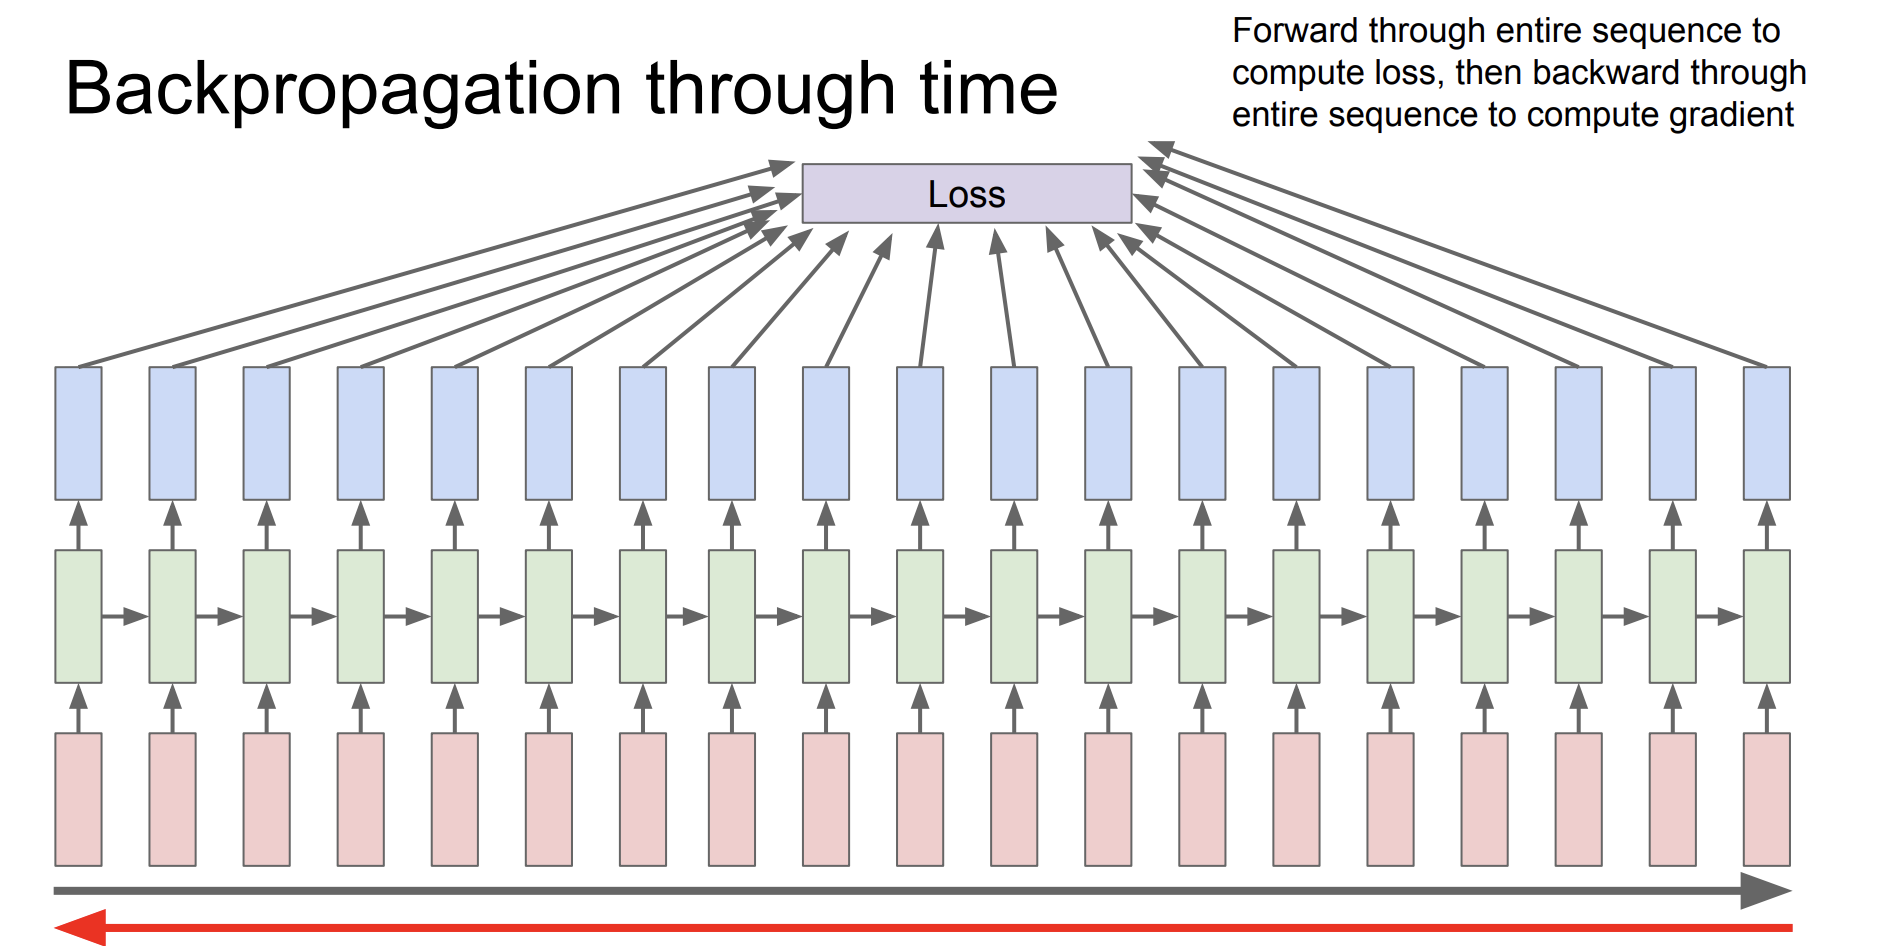 </br> </br>

$\dfrac{\partial L}{\partial \theta} = \sum^{T}_{t=1} \dfrac{\partial L_{t}}{\partial h_{t}} \cdot \dfrac{\partial h_{t}}{\partial \theta}$

<span style="font-size: 13px">

$L$ : 손실 함수 &#160;&#160; $\theta$ : 모델의 파라미터 &#160;&#160; $h_{t}$ : t시점의 은닉 상태 

</span>
</br>
BPTT는 각 시점에 대해서 오차를 모두 구한 후, 모든 시점의 오차에 대해서 시간 축으로 역전파를 진행하는 방식으로 모델의 파라미터를 업데이트함</br> </br>

<img src="https://fiveable.me/_next/image?url=https%3A%2F%2Fstorage.googleapis.com%2Fstatic.prod.fiveable.me%2Fsearch-images%252F%2522Backpropagation_through_time_RNNs_gradients_learning_long-term_dependencies_sequential_data_visualization_diagram%2522-20211202152611.png&w=3840&q=75" width=700> </br> </br>

BPTT는 시간축의 종속성을 고려하여 모델의 파라미터를 업데이트 하기 때문에 순차 데이터에 적합하지만,

긴 시퀀스로 오차가 멀리 전파될 때, 계산량이 많아지고 전파되는 양은 점차 적어져 기울기 소실 문제가 발생하기 쉽다는 단점이 있음

이러한 문제를 보완하기 위해 시퀀스를 일정 길이로 잘라서 오차를 역전파 시키는 Truncated BPTT 방식도 있음 </br> </br>

<img src="https://i.ibb.co/ZcDcTcV/2024-11-27-6-35-44.png" width=500>


### **순환 신경망의 한계**

순환 신경망은 시퀀스가 길어지면 계속하여 이전 시점의 정보를 잊어버리게 되어 과거의 정보를 활용하지 못하는 문제가 발생하는데,

이를 장기 의존성 (Long-term Dependency) 문제라고 함 </br> </br>

<img src="https://blog.kakaocdn.net/dn/eCXGd7/btq1e6Y92cK/OQXuOWVi9DTFcIrzAU5Zw1/img.png" width=350> </br> </br>

장기 의존성 문제의 대표적인 원인으로는 기울기 소실 문제가 있는데, 긴 시퀀스의 경우 이전 시점의 정보가 기울기 소실로 인해 제대로 학습되지 않기 때문임

또한, 순환 신경망은 모든 정보를 순차적으로 처리하기 때문에 특정 시점에서의 중요한 정보를 유지하기 어려운 구조를 가지고 있음

**순환신경망 예시**

In [ ]:
import torch
import torch.nn as nn

# 예시 데이터
x = torch.randn(1,5,5)  # (N,T,C) -> N: 배치 크기 / T: 문장 길이 / C: 차원수

# RNN 모델 정의
rnn = nn.RNN(input_size=x.size(-1),     # 입력 데이터의 차원수
             hidden_size=10,            # 은닉층의 차원수
             num_layers=2,              # 순환층의 개수
             bidirectional=False,       # 양방향 순환층을 이용할 것인지
             dropout=0.0,               # 드롭아웃 확률
             batch_first=True)          # 배치 크기가 첫번째 차원인지 -> False면 입력 데이터는 (T,N,C)로 구성되어 있어야 함

# RNN 모델 순전파
h0 = torch.zeros((2,1,10))  # 초기 은닉 상태값 -> (num_layers * 2 if bidirectional else 1, N, hidden_size) 형태
output, h_n = rnn(x, h0)    # output: 마지막 순환층의 모든 시점 은닉 상태값 / h_n: 각 순환층의 마지막 시점의 은닉 상태값

# RNN 모델 결과값 형태 출력
print(f"shape of output: {output.size()}")
print(f"shape of h_n: {h_n.size()}")

## **RNN Variations**

기존에 있던 순환 신경망의 장기 의존성 문제와 기울기 소실 문제를 해결하고자, 

LSTM (Long Short-Term Memory)이나 GRU (Gated Recurrent Units) 등의 모델이 등장하였음 </br> </br>

<img src="https://user-images.githubusercontent.com/78655692/173408222-20a919dc-b195-4917-9bd9-1539f1ab5cc0.png" width="500">

### **LSTM (Long Short-Term Memory)**

LSTM은 셀 상태(Cell State)와 게이트(Gate) 구조를 도입하여 정보를 효율적으로 저장, 업데이트, 삭제하는 능력을 갖춘 모델로,

게이트에는 망각 게이트(Forget Gate), 입력 게이트(Input Gate), 출력 게이트 (Output Gate)가 존재하며, 시그모이드 함수로 0~1 사이의 값을 가져 정보를 선택적으로 통과시키는 역할을 수행함 </br> </br>

<img src="https://www.researchgate.net/publication/351291905/figure/fig2/AS:1019551378579458@1620091399867/Complete-LSTM-architecture-with-equations-showing-how-information-moves-through-the-cell.ppm" width=400>

#### **Forget Gate**

$ f_{t} = \sigma(W_{f} \cdot [h_{t-1}, x_{t}] + b_{f}) $

<span style="font-size: 13px">

$h_{t}$ : $t$시점의 은닉 상태 &#160;&#160; $x_{t}$ : $t$시점의 입력 데이터 &#160;&#160; $\sigma$ : 시그모이드 함수 &#160;&#160; $W_{f}$ : forget gate의 가중치 &#160;&#160; $b_{f}$ : forget gate의 편향

</span>
</br>
forget gate는 이전 셀 상태 정보를 얼마나 유지하고 버릴지 결정하는 게이트로,

이전 셀 상태 정보 중 불필요한 정보만 삭제하여 과거 정보를 장기적으로 유지될 가능성을 증가시키는 역할을 함

#### **Input Gate**

$ i_{t} = \sigma(W_{i} \cdot [h_{t-1}, x_{t}] + b_{i}) $

<span style="font-size: 13px">

$h_{t}$ : $t$시점의 은닉 상태 &#160;&#160; $x_{t}$ : $t$시점의 입력 데이터 &#160;&#160; $\sigma$ : 시그모이드 함수 &#160;&#160; $W_{i}$ : input gate의 가중치 &#160;&#160; $b_{i}$ : input gate의 편향

</span>
</br>
input gate는 새로운 정보를 현재 셀 상태에 얼마나 반영할지 결정하는 게이트로,

새로운 정보를 선택적으로 받아들여 불필요한 정보로 인한 노이즈를 줄이는 역할을 함

#### **Output Gate**

$ o_{t} = \sigma(W_{o} \cdot [h_{t-1}, x_{t}] + b_{o}) $

<span style="font-size: 13px">

$h_{t}$ : $t$시점의 은닉 상태 &#160;&#160; $x_{t}$ : $t$시점의 입력 데이터 &#160;&#160; $\sigma$ : 시그모이드 함수 &#160;&#160; $W_{o}$ : output gate의 가중치 &#160;&#160; $b_{o}$ : output gate의 편향

</span>
</br>
output gate는 현재 셀 상태 정보로부터 얼마나 정보를 출력할지 결정하는 게이트로,

현재 셀 상태의 저장된 모든 정보 중 필요한 정보만 선택적으로 전달하여 은닉 상태와의 관계를 조율하고 모델이 적합한 결과를 출력할 수 있도록 돕는 역할을 함

#### **Cell State & Hidden State**

$ \tilde{C_{t}} = tanh(W_{c} \cdot [h_{t-1}, x_{t}] + b_{c}) \\
C_{t} = f_{t} * C_{t-1} + i_{t} * \tilde{C_{t}} \\
h_{t} = o_{t} * tanh(C_{t}) $

<span style="font-size: 13px">

$h_{t}$ : $t$시점의 은닉 상태 &#160;&#160; $x_{t}$ : $t$시점의 입력 데이터 &#160;&#160; $C_{t}$ : $t$시점의 셀 상태 &#160;&#160; $W_{c}$ : 셀 입력의 가중치 &#160;&#160; $b_{c}$ : 셀 입력의 편향 </br>
$f_{t}$ : $t$시점의 forget gate &#160;&#160; $i_{t}$ : $t$시점의 input gate &#160;&#160; $o_{t}$ : $t$시점의 output gate

</span>
</br>
셀 상태는 시간이 지남에 따라 중요한 정보를 유지하거나 제거하는 데 사용되기 때문에 더 오랜 시간 동안 정보를 보존하게 되어 LSTM에서 장기 메모리 역할을 담당함

또한, 셀 상태는 선형적 경로로 업데이트 되기 때문에 (Gradient Highway) 

모델 파라미터의 기울기를 계산할 때 반복된 시그모이드 함수나 tanh 함수 연산이 없어 기울기 소실 문제를 완화할 수 있음 </br> </br>

은닉 상태는 현재 시점의 셀 상태에서 필요한 정보만 선택적으로 반영된 것이기 때문에 현재 시점의 출력으로 사용되며,

정보가 비교적 짧은 시간 동안 유지되어 셀 상태와는 반대로 LSTM에서 단기 메모리 역할을 담당함 </br> </br>

따라서, LSTM의 셀 상태와 은닉 상태는 서로 협력하여 순차 데이터의 장기 및 단기 의존성을 모두 학습할 수 있도록 도움

#### **LSTM의 한계**

기존 순환 신경망보다 복잡해진 구조로 인해 계산 비용과 메모리 사용량이 증가했으며,

추가된 연산으로 인해 학습 속도가 느려지고, 대규모 데이터에서 특히 많은 시간이 소요될 수 있다는 단점이 있음

**LSTM 예시**

In [ ]:
import torch
import torch.nn as nn

# 예시 데이터
x = torch.randn(1,5,5)  # (N,T,C) -> N: 배치 크기 / T: 문장 길이 / C: 차원수

# LSTM 모델 정의
lstm = nn.LSTM(input_size=x.size(-1),     # 입력 데이터의 차원수
               hidden_size=10,            # 은닉층의 차원수
               num_layers=2,              # 순환층의 개수
               bidirectional=False,       # 양방향 순환층을 이용할 것인지
               dropout=0.0,               # 드롭아웃 확률
               batch_first=True)          # 배치 크기가 첫번째 차원인지 -> False면 입력 데이터는 (T,N,C)로 구성되어 있어야 함

# LSTM 모델 순전파
h0 = torch.zeros((2,1,10))  # 초기 은닉 상태값 -> (num_layers * 2 if bidirectional else 1, N, hidden_size) 형태
c0 = torch.zeros((2,1,10))  # 초기 셀 상태값 -> (num_layers * 2 if bidirectional else 1, N, hidden_size) 형태
output, (h_n, c_n) = lstm(x, (h0, c0))    # output: 마지막 순환층의 모든 시점 은닉 상태값 / h_n: 각 순환층의 마지막 시점의 은닉 상태값 / c_n: 각 순환층의 마지막 시점의 셀 상태값

# LSTM 모델 결과값 형태 출력
print(f"shape of output: {output.size()}")
print(f"shape of h_n: {h_n.size()}")
print(f"shape of c_n: {c_n.size()}")

### **GRU (Gated Recurrent Unit)**

GRU는 LSTM을 간소화시킨 버전으로, LSTM과 비슷한 역할과 성능을 보이는 모델임

리셋 게이트(Reset Gate)와 업데이트 게이트(Update Gate)만 존재하고, 별도의 셀 상태 없이 은닉 상태 하나로만 모든 정보를 관리하는 특징을 가지고 있는데,

LSTM에 비해 파라미터 수가 적고 비교적 구조가 단순해 더 빠른 학습이 가능하고 계산 효율성이 좋음 </br> </br>

<img src="https://postfiles.pstatic.net/MjAyMDA2MDZfMjU5/MDAxNTkxNDQ1ODAwMDk4.U_avbXLQisbAdpFnWnTdZg-UEJCqh8a9ODl8Sq7mA_Yg.QK3E2jgPAZk-c-AxLxF6DHKpZVxjJaX4cypwQyJSPbEg.PNG.winddori2002/2.PNG?type=w773" width=500>

#### **Reset Gate**

$ r_{t} = \sigma(W_{r} \cdot [h_{t-1}, x_{t}] + b_{r}) $

<span style="font-size: 13px">

$h_{t}$ : $t$시점의 은닉 상태 &#160;&#160; $x_{t}$ : $t$시점의 입력 데이터 &#160;&#160; $\sigma$ : 시그모이드 함수 &#160;&#160; $W_{r}$ : reset gate의 가중치 &#160;&#160; $b_{r}$ : reset gate의 편향

</span>
</br>
reset gate는 이전 은닉 상태 정보에서 얼마나 많은 정보를 제거할지를 결정하는 게이트로,

불필요한 과거 정보를 제거하는 역할을 수행함

#### **Update Gate**

$ z_{t} = \sigma(W_{z} \cdot [h_{t-1}, x_{t}] + b_{z}) $

<span style="font-size: 13px">

$h_{t}$ : $t$시점의 은닉 상태 &#160;&#160; $x_{t}$ : $t$시점의 입력 데이터 &#160;&#160; $\sigma$ : 시그모이드 함수 &#160;&#160; $W_{z}$ : update gate의 가중치 &#160;&#160; $b_{z}$ : update gate의 편향

</span>
</br>
update gate는 이전 은닉 상태 정보를 얼마나 유지할지, 현재 입력으로 얼마나 새롭게 업데이트할지를 결정하는 게이트로,

LSTM의 forget gate와 input gate를 결합한 게이트라고 볼 수 있으며,

현재 시점의 입력과 이전 은닉 상태에서 중요한 정보를 선택적으로 유지하고, 불필요한 정보는 잊도록 조절하는 역할을 수행함

#### **Hidden State**

$ \tilde{h_{t}} = tanh(W_{h} \cdot [r_{t}*h_{t-1}, x_{t}] + b_{h}) \\
h_{t} = (1 - z_{t} ) * h_{t-1} + z_{t} * \tilde{h_{t}} $

<span style="font-size: 13px">

$h_{t}$ : $t$시점의 은닉 상태 &#160;&#160; $x_{t}$ : $t$시점의 입력 데이터 &#160;&#160; $W_{h}$ : 셀 입력의 가중치 &#160;&#160; $b_{h}$ : 셀 입력의 편향 </br>
$r_{t}$ : $t$시점의 reset gate &#160;&#160; $z_{t}$ : $t$시점의 update gate

</span>
</br>
GRU의 은닉 상태는 LSTM의 셀 상태와 은닉 상태를 결합란 것이라고 볼 수 있으며,

update gate와 reset gate에 의해 지속적으로 업데이트 되기 때문에

시점 간의 정보 흐름을 관리하고, 모델이 장기적으로 중요한 정보를 기억하도록 돕는 메모리 역할을 수행함

또한, 시점별 은닉 상태는 모델의 시점별 출력으로도 활용됨

#### **GRU의 한계**

LSTM만큼 세밀한 조정이 불가능하여, 매우 복잡한 시퀀스 패턴이나 정교한 장기 의존성을 학습하는 데 한계가 있으며,

일부 데이터에서는 단순화된 구조가 단점으로 작용해 LSTM보다 성능이 떨어질 수 있음

**GRU 예시**

In [ ]:
import torch
import torch.nn as nn

# 예시 데이터
x = torch.randn(1,5,5)  # (N,T,C) -> N: 배치 크기 / T: 문장 길이 / C: 차원수

# GRU 모델 정의
gru = nn.GRU(input_size=x.size(-1),     # 입력 데이터의 차원수
             hidden_size=10,            # 은닉층의 차원수
             num_layers=2,              # 순환층의 개수
             bidirectional=False,       # 양방향 순환층을 이용할 것인지
             dropout=0.0,               # 드롭아웃 확률
             batch_first=True)          # 배치 크기가 첫번째 차원인지 -> False면 입력 데이터는 (T,N,C)로 구성되어 있어야 함

# GRU 모델 순전파
h0 = torch.zeros((2,1,10))  # 초기 은닉 상태값 -> (num_layers * 2 if bidirectional else 1, N, hidden_size) 형태
output, h_n = gru(x, h0)    # output: 마지막 순환층의 모든 시점 은닉 상태값 / h_n: 각 순환층의 마지막 시점의 은닉 상태값

# GRU 모델 결과값 형태 출력
print(f"shape of output: {output.size()}")
print(f"shape of h_n: {h_n.size()}")

## **다양한 자연어처리 태스크**

### **문장 분류 (Sentence Classification)**

<img src="https://blog.kakaocdn.net/dn/suvUc/btrM8l44TuG/2URVkEUetgI1Sb5okPmayK/img.png" width=450> </br> </br>

문장 분류는 주어진 문장 전체를 하나의 카테고리로 분류하는 태스크로, 주로 문장 수준에서의 의미를 파악하여 해당 문장이 어떤 종류에 속하는지 분류를 수행함

문장이 긍정적인지 부정적인지를 판단하는 감정 분석(sentiment analysis)이나 문장이 어떤 주제에 해당하는지를 분류하는 태스크 등이 있음

### **토큰 분류 (Token Classification)**

<img src="https://velog.velcdn.com/images/tbvjvsladla/post/dfac766e-679c-463c-a114-14308eb3d8c2/image.png" width=400> </br> </br>

토큰 분류는 문장을 구성하는 각 토큰을 개별적으로 분류하는 태스크로, 주로 문장에서 의미 있는 단어들을 분리하고 각 단어가 어떤 종류에 속하는지 분류를 수행함

주어진 문장에서 각 단어의 개체명을 분류하는 개체명 인식 (Named Entity Recognition, NER), 각 단어의 품사를 예측하는 품사 태깅 (Part-of-Speech Tagging) 태스크 등이 있음

### **문장 생성 (Sentence Generation)**

<img src="https://wikidocs.net/images/page/24996/%EC%9D%B8%EC%BD%94%EB%8D%94%EB%94%94%EC%BD%94%EB%8D%94%EB%AA%A8%EB%8D%B8.PNG" width=600> </br> </br>

문장 생성은 주어진 입력을 바탕으로 새로운 문장을 생성하는 태스크로, 정확하고 자연스러운 문장을 생성하는 것이 목표임

한 언어로 된 문장을 다른 언어로 번역(Translation)하는 태스크, 질문에 대한 적절한 답변을 생성하는 질의응답 (Question Answering, QA) 태스크, 원본 문장을 짧은 문장으로 요약(Summarization)하는 태스크 등이 있음